# 03 — Feature Engineering
## FairLend-Africa Research Project

Documents all feature engineering decisions made before model training.
Each decision is justified on behavioral finance grounds, not just
statistical convenience. This notebook produces the final feature set
used in model training.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 130

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../artifacts/features").mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv("../data/synthetic/fairlend_dataset.csv")
print(f"Raw shape: {df.shape}")

Raw shape: (10000, 21)


### 1. Derived features
We engineer three composite features that better capture
behavioral creditworthiness signals than raw features alone.

**Rationale:** Feature engineering decisions are grounded in
behavioral finance literature on mobile money usage as a
creditworthiness proxy (Björkegren & Grissen, 2018).

In [3]:
df_feat = df.copy()

# 1. Transaction intensity score
# Captures both frequency and value of transactions together.
# A borrower with high frequency but tiny amounts differs from
# one with moderate frequency and higher amounts.
df_feat["txn_intensity"] = (
    np.log1p(df_feat["monthly_txn_count"]) *
    np.log1p(df_feat["avg_txn_amount_usd"])
).round(4)

# 2. Savings commitment ratio
# Ratio of monthly savings to average transaction amount.
# Captures whether the borrower actively sets money aside
# relative to their transaction activity.
df_feat["savings_commitment_ratio"] = (
    df_feat["monthly_savings_usd"] /
    (df_feat["avg_txn_amount_usd"] + 1)  # +1 avoids division by zero
).round(4)

# 3. Airtime consistency score
# Frequent small recharges signal liquidity stress;
# infrequent larger recharges signal more stable cash flow.
# Higher ratio = more stable pattern.
df_feat["airtime_stability"] = (
    df_feat["airtime_avg_amount_usd"] /
    (df_feat["airtime_recharge_freq"] + 1)
).round(4)

print("Derived features added:")
print(df_feat[["txn_intensity", "savings_commitment_ratio", "airtime_stability"]].describe().round(3))

Derived features added:
       txn_intensity  savings_commitment_ratio  airtime_stability
count      10000.000                 10000.000          10000.000
mean          10.772                     0.263              0.242
std            3.057                     0.480              0.157
min            1.975                     0.000              0.027
25%            8.570                     0.000              0.141
50%           10.627                     0.000              0.204
75%           12.838                     0.391              0.297
max           22.991                     7.828              3.305


### 2. Missing value strategy
`prior_loan_repayment_rate` and `days_late_avg` are MNAR.
We add a binary **missingness indicator** for each.
This preserves the information that a borrower has no credit
history, rather than silently imputing it away.
The actual NaN values will still be median-imputed inside
the sklearn Pipeline for model compatibility.

In [4]:
df_feat["no_prior_loan_flag"] = df_feat["prior_loan_repayment_rate"].isnull().astype(int)

print("Missingness indicator added:")
print(df_feat["no_prior_loan_flag"].value_counts())
print(f"\nVerification — matches has_prior_loan==0: "
      f"{(df_feat['no_prior_loan_flag'] == (1 - df_feat['has_prior_loan'])).all()}")

Missingness indicator added:
no_prior_loan_flag
1    5503
0    4497
Name: count, dtype: int64

Verification — matches has_prior_loan==0: True


### 3. Final feature set
We explicitly define which features enter the model and why.
Demographic attributes (region, gender, age, occupation)
are **excluded from model features** to prevent direct
demographic discrimination, consistent with fair lending principles.
They are retained in the dataset solely for fairness auditing.

In [5]:
FINAL_FEATURE_COLS = [
    # Raw behavioral features
    "monthly_txn_count",
    "avg_txn_amount_usd",
    "wallet_balance_trend",
    "airtime_recharge_freq",
    "airtime_avg_amount_usd",
    "has_savings_account",
    "savings_consistency_score",
    "monthly_savings_usd",
    "has_prior_loan",
    "prior_loan_repayment_rate",   # MNAR — will be imputed
    "days_late_avg",               # MNAR — will be imputed
    "network_diversity_score",
    "bill_payment_regularity",
    "merchant_payment_count",
    "loan_amount_requested_usd",
    "loan_duration_weeks",
    # Engineered features
    "txn_intensity",
    "savings_commitment_ratio",
    "airtime_stability",
    "no_prior_loan_flag",
]

DEMOGRAPHIC_COLS = ["region", "gender", "age", "occupation"]
TARGET_COL = "repaid"

print(f"Final feature count: {len(FINAL_FEATURE_COLS)}")
print(f"Features excluded (demographic): {DEMOGRAPHIC_COLS}")
print(f"\nAll features present: "
      f"{all(c in df_feat.columns for c in FINAL_FEATURE_COLS)}")

Final feature count: 20
Features excluded (demographic): ['region', 'gender', 'age', 'occupation']

All features present: True


In [6]:
check_cols = FINAL_FEATURE_COLS + [TARGET_COL]
corr = df_feat[check_cols].fillna(df_feat[check_cols].median()).corr()
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

print("All feature correlations with repayment label:\n")
print(f"  {'Feature':<35} {'r':>8}")
print("  " + "-" * 46)
for feat, val in target_corr.items():
    marker = " ← new" if feat in ["txn_intensity","savings_commitment_ratio","airtime_stability","no_prior_loan_flag"] else ""
    print(f"  {feat:<35} {val:>+.4f}{marker}")

All feature correlations with repayment label:

  Feature                                    r
  ----------------------------------------------
  wallet_balance_trend                +0.2344
  has_savings_account                 +0.1973
  savings_consistency_score           +0.1935
  monthly_savings_usd                 +0.1689
  monthly_txn_count                   +0.1470
  txn_intensity                       +0.1365 ← new
  savings_commitment_ratio            +0.1249 ← new
  airtime_recharge_freq               +0.1144
  merchant_payment_count              +0.1108
  airtime_avg_amount_usd              +0.0859
  avg_txn_amount_usd                  +0.0794
  bill_payment_regularity             +0.0509
  loan_amount_requested_usd           +0.0496
  network_diversity_score             +0.0454
  prior_loan_repayment_rate           +0.0352
  airtime_stability                   +0.0210 ← new
  has_prior_loan                      +0.0142
  loan_duration_weeks                 -0.0074
  no_prior

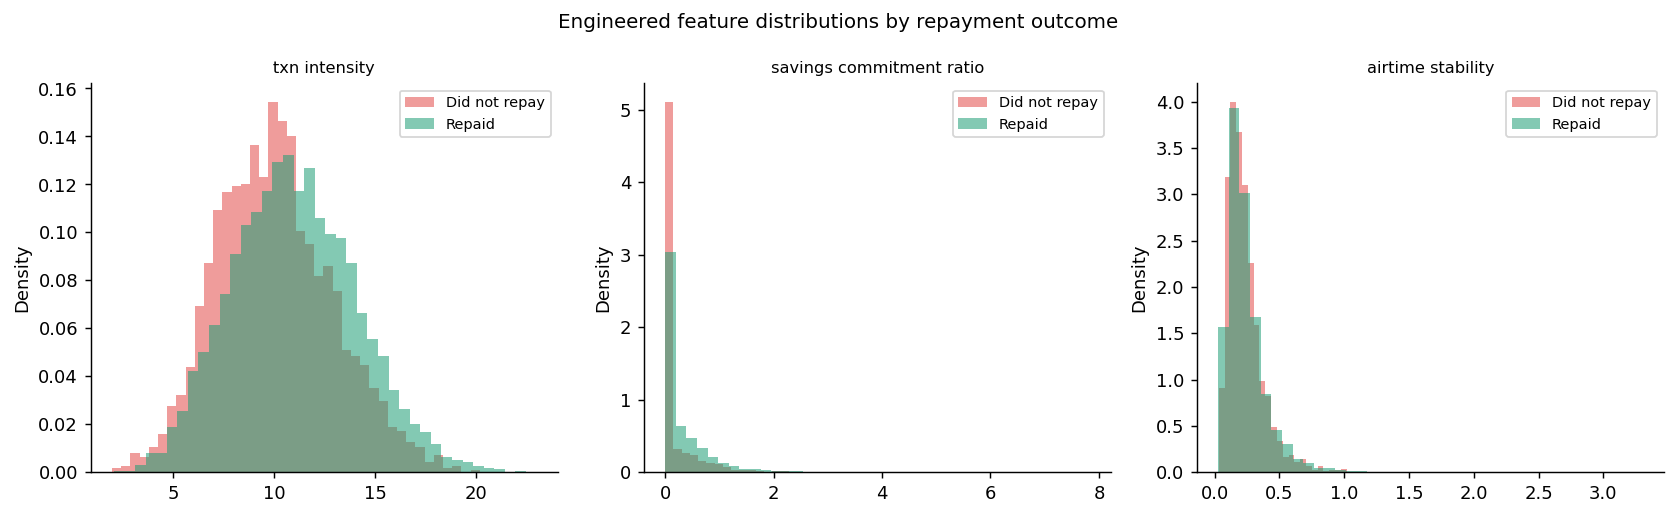

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

new_features = ["txn_intensity", "savings_commitment_ratio", "airtime_stability"]

for ax, feat in zip(axes, new_features):
    for label, color, name in [
        (0, "#E24B4A", "Did not repay"),
        (1, "#1D9E75", "Repaid")
    ]:
        subset = df_feat[df_feat[TARGET_COL] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.55, color=color,
                label=name, density=True, edgecolor="none")
    ax.set_title(feat.replace("_", " "), fontsize=9)
    ax.set_ylabel("Density")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle("Engineered feature distributions by repayment outcome", fontsize=11)
plt.tight_layout()
plt.savefig("../artifacts/features/engineered_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
df_processed = df_feat[DEMOGRAPHIC_COLS + FINAL_FEATURE_COLS + [TARGET_COL]]
df_processed.to_csv("../data/processed/fairlend_processed.csv", index=False)

print(f"✓ Saved: data/processed/fairlend_processed.csv")
print(f"  Shape: {df_processed.shape}")
print(f"  Features: {len(FINAL_FEATURE_COLS)}")
print(f"  Columns: {list(df_processed.columns)}")

✓ Saved: data/processed/fairlend_processed.csv
  Shape: (10000, 25)
  Features: 20
  Columns: ['region', 'gender', 'age', 'occupation', 'monthly_txn_count', 'avg_txn_amount_usd', 'wallet_balance_trend', 'airtime_recharge_freq', 'airtime_avg_amount_usd', 'has_savings_account', 'savings_consistency_score', 'monthly_savings_usd', 'has_prior_loan', 'prior_loan_repayment_rate', 'days_late_avg', 'network_diversity_score', 'bill_payment_regularity', 'merchant_payment_count', 'loan_amount_requested_usd', 'loan_duration_weeks', 'txn_intensity', 'savings_commitment_ratio', 'airtime_stability', 'no_prior_loan_flag', 'repaid']


## Feature engineering summary

| Feature | Type | Rationale |
|---|---|---|
| `txn_intensity` | Derived | Combines frequency and value of transactions |
| `savings_commitment_ratio` | Derived | Savings relative to transaction activity |
| `airtime_stability` | Derived | Stable airtime pattern vs stress recharging |
| `no_prior_loan_flag` | Indicator | Preserves MNAR information from missing credit history |

**Total features entering model: 20**
(16 raw behavioral + 3 derived composite + 1 missingness indicator)

Demographic features are retained in the dataset but
excluded from model training inputs.